In [1]:
# ─────────────────────────────────────────────
# 0 : Loading
# ─────────────────────────────────────────────

%load_ext autoreload
%autoreload 2

In [1]:
# ─────────────────────────────────────────────
# 1.1 : Python Version
# ─────────────────────────────────────────────

import sys, site
print("Python:", sys.executable)
print("User site:", site.getusersitepackages())
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")


# ─────────────────────────────────────────────
# 1.2 : Librairies
# ─────────────────────────────────────────────

import numpy as np
import polars as pl

from pathlib import Path
from matplotlib import pyplot as plt

from nucleo.io.reading import getting_main_file_with_verifications

plt.rcParams["font.size"] = 16

Python: /home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/bin/python
User site: /home/nicolas/.local/lib/python3.12/site-packages
Site-packages: ['/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/site-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/local/lib/python3.12/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/dist-packages']


In [5]:
# ─────────────────────────────────────────────
# 2.1 : Functions
# ─────────────────────────────────────────────

# Datas

def data_one_scen(df: pl.DataFrame, scen: dict) -> pl.DataFrame:
    return df.filter(
        (pl.col("land") == scen["land"])
        & (pl.col("s") == scen["s"])
        & (pl.col("l") == scen["l"])
        & (pl.col("bpmin") == scen["bpmin"])
    )


# Cuts 

def cut_1_mu(df: pl.DataFrame, scen: dict, mu: int) -> pl.DataFrame:
    return df.filter(
        (pl.col("land") == scen["land"])
        & (pl.col("s") == scen["s"])
        & (pl.col("l") == scen["l"])
        & (pl.col("bpmin") == scen["bpmin"])
        & (pl.col("mu") == mu)
    )
    
def cut_1_theta(df: pl.DataFrame, scen: dict, theta: int) -> pl.DataFrame:
    return df.filter(
        (pl.col("land") == scen["land"])
        & (pl.col("s") == scen["s"])
        & (pl.col("l") == scen["l"])
        & (pl.col("bpmin") == scen["bpmin"])
        & (pl.col("theta") == theta)
    )
    
def cut_1_l(df: pl.DataFrame, scen: dict, mu: int,  theta: int) -> pl.DataFrame:
    return df.filter(
        (pl.col("land") == scen["land"])
        & (pl.col("s") == scen["s"])
        & (pl.col("bpmin") == scen["bpmin"])
        & (pl.col("mu") == mu)
        & (pl.col("theta") == theta)
    )


# ─────────────────────────────────────────────
# 2.2 : Getting datas
# ─────────────────────────────────────────────

# Root
root = Path.home() / "Documents" / "Workspace" / "nucleo" / "outputs" / "NUCLEO__PSMN__2026-06-19"

# Reading 
path_datas = root / "ncl_output.parquet"
df_all = pl.read_parquet(path_datas)

# Loading + Filtering
df_secured = getting_main_file_with_verifications(df_all)

# Ordering
df_sorted = df_secured.sort(
        by=["s", "land", "bpmin", "l"] ,
        descending=[False, False, False, False]
    )
# print(df_sorted)

# ─────────────────────────────────────────────
# 2.3 : Reading Scenarios
# ─────────────────────────────────────────────

# Reading
path_scenario = root / "scenarios.json"
df_all_scen = pl.read_json(path_scenario)

# Ordering
df_all_scen_ordered = df_all_scen.sort(
        by=["s", "land", "bpmin", "l"] ,
        descending=[False, False, False, False]
    )
# print(df_all_scen_ordered)


# ─────────────────────────────────────────────
# 2.4 : Prints
# ─────────────────────────────────────────────

print("All scenarios:\n", df_all_scen_ordered)
df_scen_work = df_all_scen_ordered[2]
print("Working on :\n", df_scen_work)

All scenarios:
 shape: (20, 4)
┌─────┬─────┬───────┬──────────┐
│ s   ┆ l   ┆ bpmin ┆ land     │
│ --- ┆ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64 ┆ i64   ┆ str      │
╞═════╪═════╪═══════╪══════════╡
│ 150 ┆ 10  ┆ 0     ┆ homogen  │
│ 150 ┆ 5   ┆ 0     ┆ periodic │
│ 150 ┆ 10  ┆ 0     ┆ periodic │
│ 150 ┆ 15  ┆ 0     ┆ periodic │
│ 150 ┆ 20  ┆ 0     ┆ periodic │
│ …   ┆ …   ┆ …     ┆ …        │
│ 150 ┆ 100 ┆ 0     ┆ random   │
│ 150 ┆ 150 ┆ 0     ┆ random   │
│ 150 ┆ 10  ┆ 5     ┆ random   │
│ 150 ┆ 10  ┆ 10    ┆ random   │
│ 150 ┆ 10  ┆ 15    ┆ random   │
└─────┴─────┴───────┴──────────┘
Working on :
 shape: (1, 4)
┌─────┬─────┬───────┬──────────┐
│ s   ┆ l   ┆ bpmin ┆ land     │
│ --- ┆ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64 ┆ i64   ┆ str      │
╞═════╪═════╪═══════╪══════════╡
│ 150 ┆ 10  ┆ 0     ┆ periodic │
└─────┴─────┴───────┴──────────┘


⚠️ 20200 lignes dupliquées sur (theta, mu) détectées, dédoublonnage automatique


/tmp/ipykernel_9623/2054049057.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


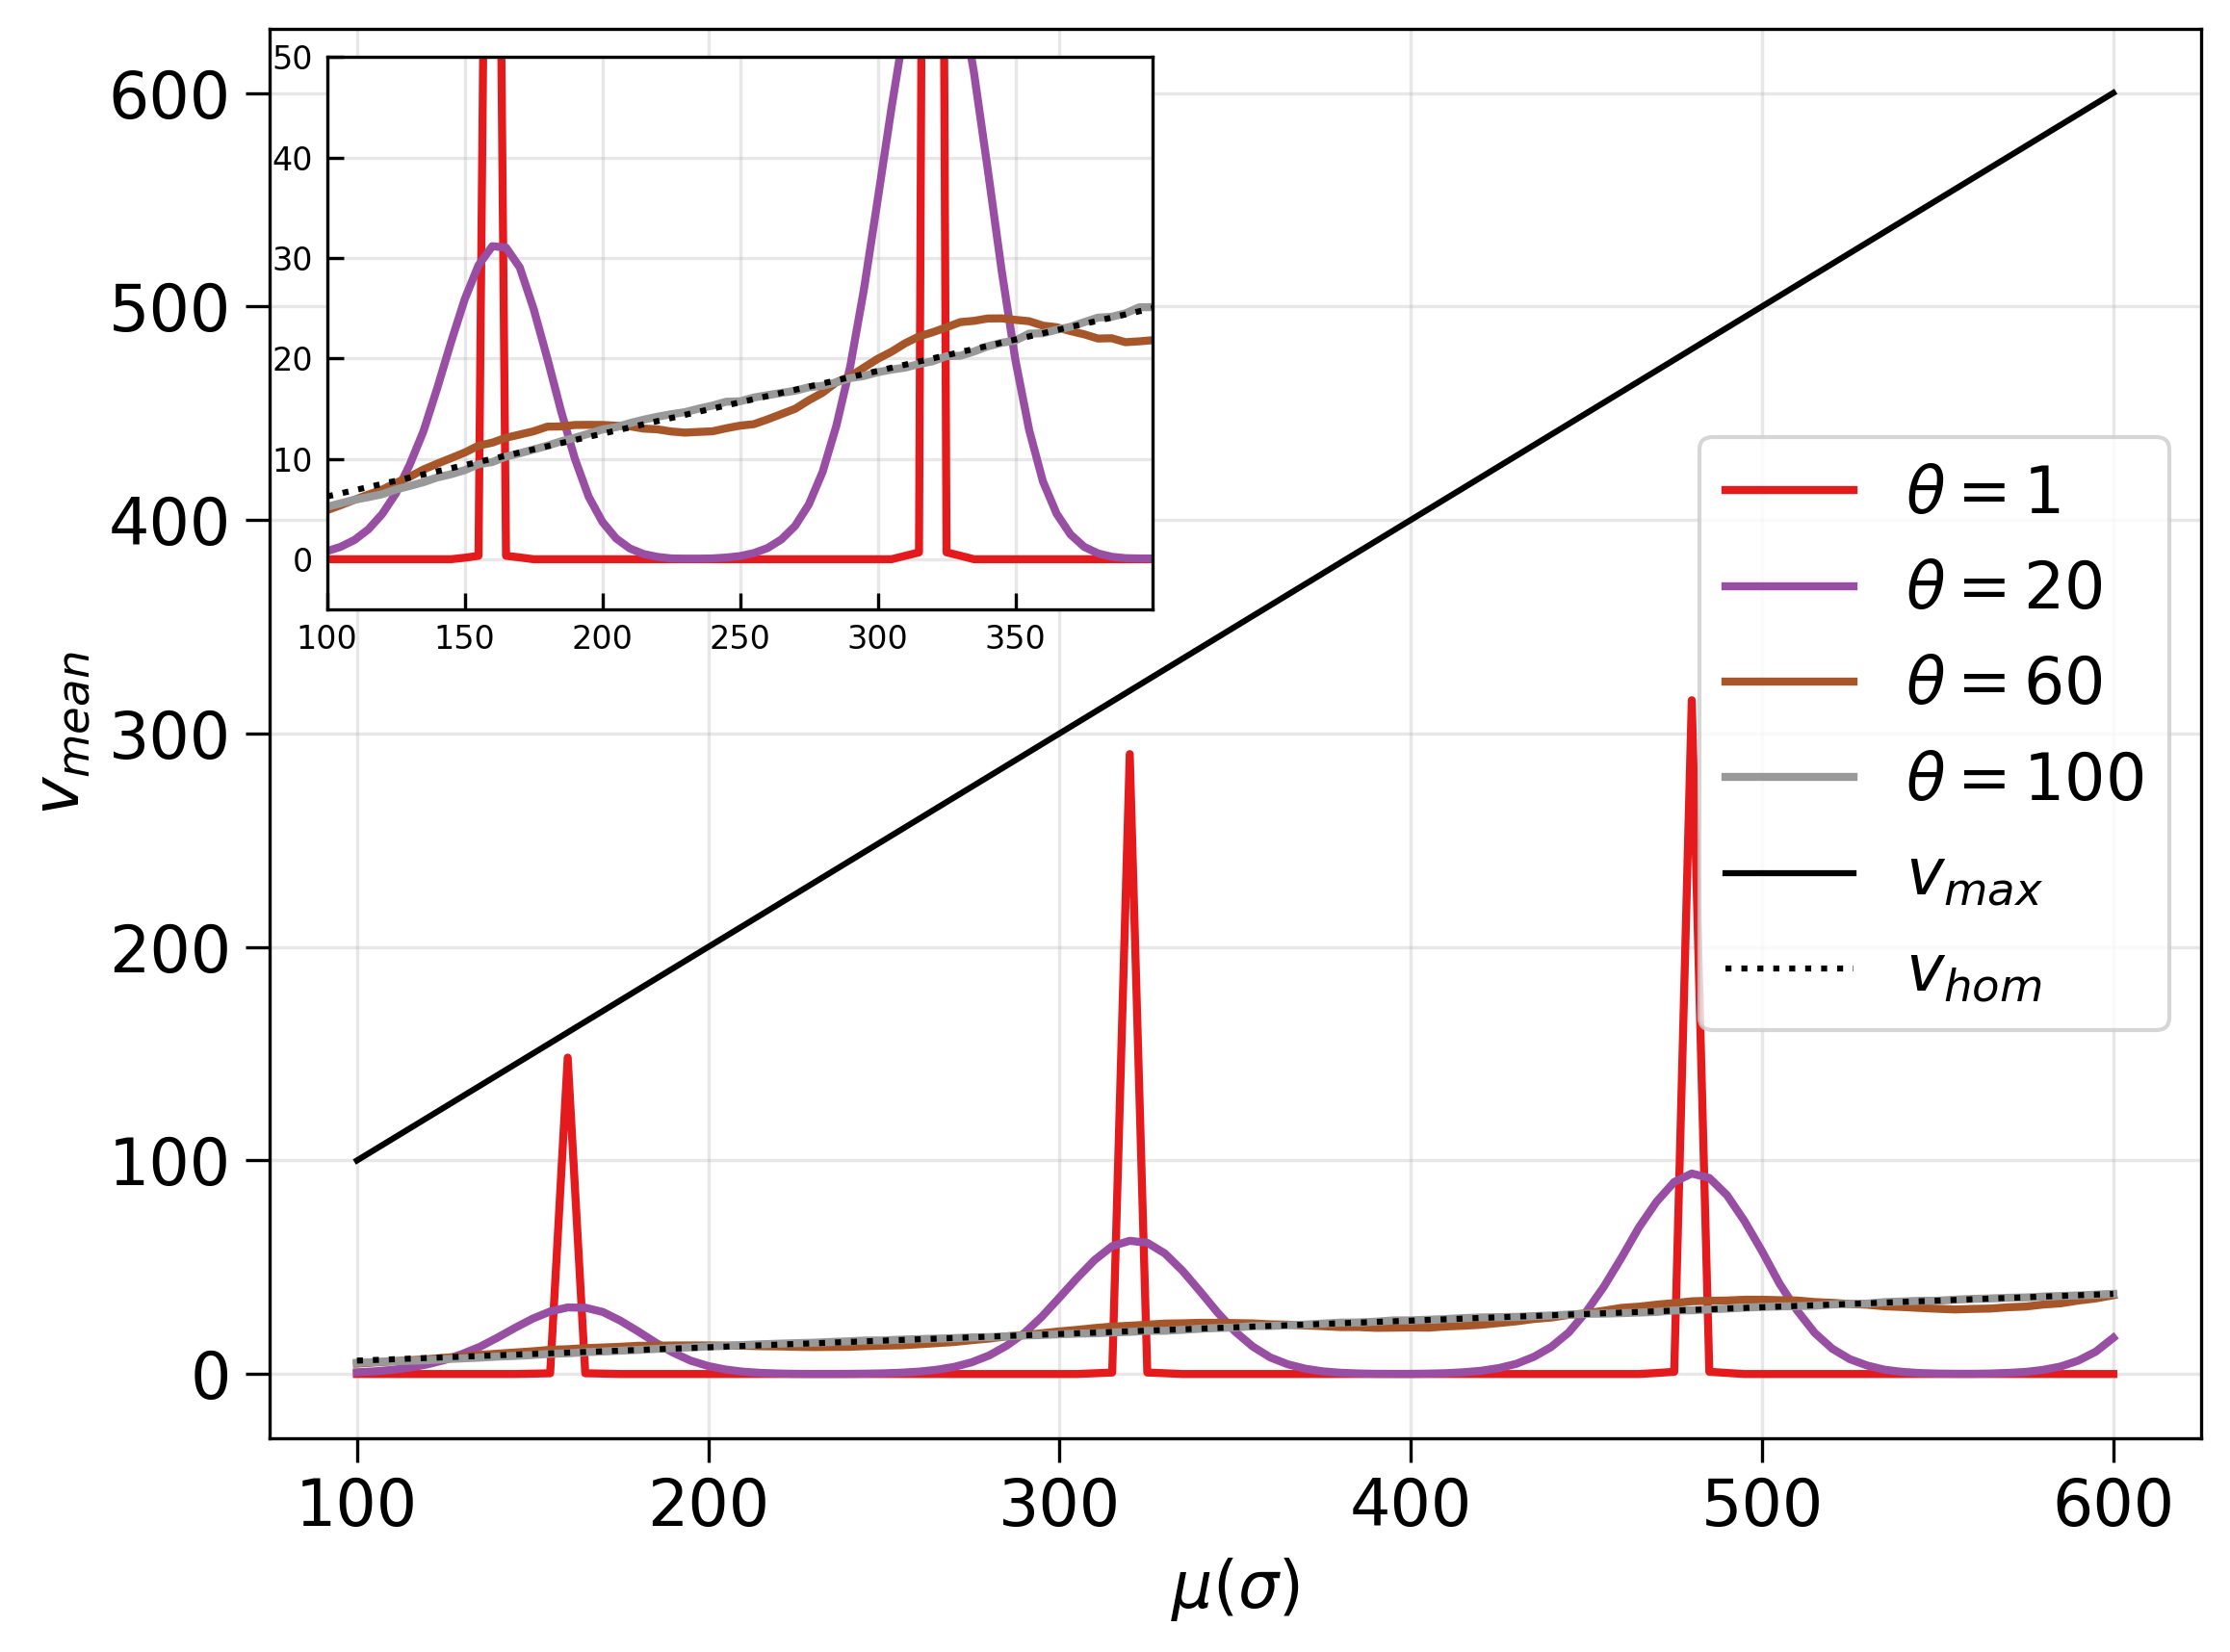

In [7]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

plt.rcParams["font.size"] = 16
fontsize = 16

# ── Sélection du scénario ────────────────────────────────────────────────────

df_work = df_sorted.filter(
    (df_sorted["land"] == df_scen_work["land"]) &
    (df_sorted["s"] == df_scen_work["s"]) &
    (df_sorted["l"] == df_scen_work["l"]) &
    (df_sorted["bpmin"] == df_scen_work["bpmin"])
)

# Sécurité : on déduplique pour éviter d'avoir 2 lignes par (theta, mu)
# (vérifie d'où viennent ces doublons si ce print n'est pas vide)
dupes = df_work.filter(pl.struct(["theta", "mu"]).is_duplicated())
if dupes.height > 0:
    print(f"⚠️ {dupes.height} lignes dupliquées sur (theta, mu) détectées, dédoublonnage automatique")
df_work = df_work.unique(subset=["theta", "mu"], keep="first")

mus = np.unique(df_work["mu"].to_numpy())
thetas = np.unique(df_work["theta"].to_numpy())

thetas = np.array([1, 20, 60, 100])
mus = np.array([160, 200, 240])

# ── Couleurs (cohérentes avec les cellules suivantes de cette section) ──────
cmap_1 = plt.get_cmap("Set1")
cmap_2 = plt.get_cmap("Set1")
colors_1 = [cmap_1(i / (len(thetas) - 1)) for i in range(len(thetas))]
colors_2 = [cmap_2(i / (len(mus) - 1)) for i in range(len(mus))]

# ── Data pour la coupe en mu ─────────────────────────────────────────────────
df_all_plot = df_work.filter(
    pl.col("theta").is_in(thetas)
)

title = df_all_plot["land"][0]
if title == "nt_random":
    title = "Random"

# ── Courbe homogène (v_max et v_hom) calculée une seule fois, sur un mu propre
df_homog = (
    df_all_plot
    .with_columns(
        ((pl.col("alphaf") * pl.col("l") + pl.col("alphao") * pl.col("s"))
         / (pl.col("l") + pl.col("s"))).alias("alpha_mean")
    )
    .group_by("mu")
    .agg(pl.col("alpha_mean").mean())
    .sort("mu")
)

mu_hom = df_homog["mu"].to_numpy()
v_hom = mu_hom * df_homog["alpha_mean"].to_numpy()

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.tick_params(
    axis="both",
    which="both",
    direction="out",
    labelsize=16,
    length=6
)

for (col, theta) in zip(colors_1, thetas):
    df_one_plot = (
        df_all_plot
        .filter(pl.col("theta") == theta)
        .sort("mu", descending=False)
    )

    mu_plot = df_one_plot["mu"].to_numpy()
    v_mean = df_one_plot["v_mean"].to_numpy()

    ax.plot(mu_plot, v_mean, color=col, lw=2, label=f"$\\theta={theta}$")

ax.plot(mu_hom, mu_hom, label="$v_{max}$", color="black", ls="-")
ax.plot(mu_hom, v_hom, label="$v_{hom}$", color="black", ls=":")

ax.set_xlabel("$\\mu(\\sigma)$", fontsize=fontsize)
ax.set_ylabel("$v_{mean}$", fontsize=fontsize)
ax.grid(True, alpha=0.3)
ax.legend(loc="center right", ncols=1)

# ── Inset zoom ───────────────────────────────────────────────────────────────
axins = inset_axes(
    ax,
    width="45%",
    height="40%",
    loc="upper left",
    bbox_to_anchor=(0.03, 0.0, 0.95, 0.98),
    bbox_transform=ax.transAxes,
    borderpad=0
)

for (col, theta) in zip(colors_1, thetas):
    df_one_plot = (
        df_all_plot
        .filter(pl.col("theta") == theta)
        .sort("mu", descending=False)
    )

    mu_plot = df_one_plot["mu"].to_numpy()
    v_mean = df_one_plot["v_mean"].to_numpy()

    axins.plot(mu_plot, v_mean, color=col, lw=2)

axins.plot(mu_hom, mu_hom, color="black", ls="-")
axins.plot(mu_hom, v_hom, color="black", ls=":")

axins.set_xticks([100, 150, 200, 250, 300, 350])
axins.set_yticks([0, 10, 20, 30, 40, 50])

axins.tick_params(
    axis="both",
    which="both",
    direction="in",
    labelsize=8,
    length=4,
    width=0.8
)

axins.set_xlim(100, 400)
axins.set_ylim(-5, 50)
axins.grid(True, alpha=0.3)

# Relier la zone zoomée
# mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.show()

In [8]:

# ─────────────────────────────────────────────
# FIG 2.C.2 : Cuts Of Hetmaps - µ Values
# ─────────────────────────────────────────────

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

mus = np.array([160, 200, 240])

df_all_plot = df_work.filter(
    pl.col("mu").is_in(mus)
)

title = df_all_plot["land"][0]
if title == "nt_random":
    title = "Random"

# --- Figure ---
plt.figure(figsize=(12,6), dpi=1200)

ax = plt.gca()  # on récupère l'axe courant

for mu, col in zip(mus, colors_2):

    df_one_plot = (
        df_all_plot
        .filter(pl.col("mu") == mu)
        .sort("theta")
    )

    theta  = df_one_plot["theta"].to_numpy()
    v_mean = df_one_plot["v_mean"].to_numpy()

    # courbe principale
    plt.plot(
        theta, v_mean,
        marker="o", lw=2,
        color=col,
        label=rf"$\mu={mu}$"
    )

    # ligne horizontale associée
    plt.axhline(
        y=alpha_mean[0] * mu,
        ls=":", lw=2,
        color=col
    )

# --- Labels ---
plt.xlabel(r"$\theta(\sigma)$")
plt.ylabel("$v_{mean}$")
plt.grid(True, alpha=0.3, which="both")
plt.legend(
    loc="upper left",
    bbox_to_anchor=(0.15, 1.0)
)

# ─────────────────────────
#          INSET
# ─────────────────────────

axins = inset_axes(ax, width="50%", height="50%", loc="upper right")


# données de la courbe rouge (mu=160)
mu_ref = 160
col_ref = colors_2[0]

df_ref = (
    df_all_plot
    .filter(pl.col("mu") == mu_ref)
    .sort("theta")
)

theta = df_ref["theta"].to_numpy()
v_mean = df_ref["v_mean"].to_numpy()

# courbe réelle
axins.loglog(
    theta,
    v_mean,
    "o-",
    color=col_ref,
    lw=2,
    label="Simulation"
)

# loi d'échelle theta^{-1}
A = v_mean[-1] * theta[-1]      # normalisation

theta_fit = np.linspace(theta.min(), theta.max(), 500)
v_fit = A * theta_fit**(-1)

axins.loglog(
    theta_fit[50:300],
    v_fit[50:300],
    "-.k",
    lw=2
)

axins.text(
    0.93, 0.65,                         # (x,y) en coordonnées d'axe
    r"$\propto \theta^{-1}$",
    transform=ax.transAxes,
    fontsize=16,
    color="black",
    ha="right",
    va="bottom",
    rotation=-40
)

# axins.legend(fontsize=7)
axins.grid(True, which="both", alpha=0.3)

axins.tick_params(
    axis="both",
    which="both",
    direction="in",
    labelsize=8,
    length=4,
    width=0.8
)

# axins.set_xlabel(r"$\theta$", fontsize=8)
# axins.set_ylabel(r"$v_{mean}$", fontsize=8)

In [12]:
# ─────────────────────────────────────────────
# FIG : DATA
# ─────────────────────────────────────────────

df_scen_work = df_all_scen_ordered[2]
print("Working on :\n", df_scen_work)

df_work = df_sorted.filter(
    (df_sorted["land"] == df_scen_work["land"]) &
    (df_sorted["s"] == df_scen_work["s"]) &
    (df_sorted["l"] == df_scen_work["l"]) &
    (df_sorted["bpmin"] == df_scen_work["bpmin"])
)
print(df_work)

mus = np.unique(df_work["mu"].to_numpy())
thetas = np.unique(df_work["theta"].to_numpy())
print(mus, thetas)


thetas = np.array([1, 20, 60, 100])
mus = np.array([160, 200, 240])

cmap_1 = plt.get_cmap("Set1")
cmap_2 = plt.get_cmap("Set1")
colors_1 = [cmap_1(i / (len(thetas) - 1)) for i in range(len(thetas))]
colors_2 = [cmap_2(i / (len(mus) - 1)) for i in range(len(mus))]



# ─────────────────────────────────────────────
# FIG : wf vs theta (cuts at fixed mu)
# ─────────────────────────────────────────────

mus_cut = 160

df_all_plot = df_work.filter(
    pl.col("mu").is_in(mus_cut)
)

thetas = np.unique(df_all_plot["theta"].to_numpy())

# colormap
color = "tab:green"

plt.figure(figsize=(8,6), dpi=1200)
ax = plt.gca()

# =========================
# main curves: wf(theta)
# =========================

df_mu = (
    df_all_plot
    .filter(pl.col("mu") == mus_cut)
    .sort("theta")
)

theta = df_mu["theta"].to_numpy()
wf    = df_mu["wf"].to_numpy()

ax.plot(
    theta, wf,
    marker="o",
    lw=2,
    color=color
)

ax.axhline(y=1, c="k", ls=":")
ax.set_ylim([0.90, 1.10])

# =========================
# styling
# =========================

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$w_f$")
ax.grid(True, alpha=0.3)
# ax.legend(loc="best")

plt.show()

Working on :
 shape: (1, 4)
┌─────┬─────┬───────┬──────────┐
│ s   ┆ l   ┆ bpmin ┆ land     │
│ --- ┆ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64 ┆ i64   ┆ str      │
╞═════╪═════╪═══════╪══════════╡
│ 150 ┆ 10  ┆ 0     ┆ periodic │
└─────┴─────┴───────┴──────────┘
shape: (20_200, 27)
┌──────────┬─────┬─────┬───────┬───┬──────────┬─────────────┬────────────┬───────┐
│ land     ┆ s   ┆ l   ┆ bpmin ┆ … ┆ wf_std   ┆ vi_mean     ┆ vi_med     ┆ vi_mp │
│ ---      ┆ --- ┆ --- ┆ ---   ┆   ┆ ---      ┆ ---         ┆ ---        ┆ ---   │
│ str      ┆ i64 ┆ i64 ┆ i64   ┆   ┆ f64      ┆ f64         ┆ f64        ┆ f64   │
╞══════════╪═════╪═════╪═══════╪═══╪══════════╪═════════════╪════════════╪═══════╡
│ periodic ┆ 150 ┆ 10  ┆ 0     ┆ … ┆ 0.012799 ┆ 303.663419  ┆ 16.266083  ┆ 5.5   │
│ periodic ┆ 150 ┆ 10  ┆ 0     ┆ … ┆ 0.025045 ┆ 1330.388394 ┆ 34.783609  ┆ 12.5  │
│ periodic ┆ 150 ┆ 10  ┆ 0     ┆ … ┆ 0.003734 ┆ 2141.509298 ┆ 226.970078 ┆ 85.5  │
│ periodic ┆ 150 ┆ 10  ┆ 0     ┆ … ┆ 0.007573 ┆ 2295.6484

/tmp/ipykernel_9623/3521136197.py:37: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_all_plot = df_work.filter(


# .